# Setup

In [1]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import re
import enum
import plotly.graph_objects as go
import seaborn as sns

warnings.simplefilter("ignore", FutureWarning)

# Importing data from experiments json reports

## Cosine Only

In [2]:
with open('../cosine_only/2f9cbf43-0dfc-48a9-b70c-ffa66fe42500.json', 'r', encoding='utf-8') as file:
    data_cosine_only_1ex = json.load(file)['data']

with open('../cosine_only/9aacf913-c758-485f-90bb-7d26b14cfa76.json', 'r', encoding='utf-8') as file:
    data_cosine_only_5ex = json.load(file)['data']

with open('../cosine_only/e2d1c507-aa49-4f00-949c-2d3c946bf403.json', 'r', encoding='utf-8') as file:
    data_cosine_only_10ex = json.load(file)['data']

with open('../cosine_only/4d831f45-3c81-445d-9fa5-d872a24f569c.json', 'r', encoding='utf-8') as file:
    data_cosine_only_15ex = json.load(file)['data']

with open('../cosine_only/ea4c74b2-ad5d-46dd-a6e5-eac5dcd6e6b2.json', 'r', encoding='utf-8') as file:
    data_cosine_only_20ex = json.load(file)['data']

data_cosine_only = [
    {
        'number_of_examples': 1,
        'report_content': data_cosine_only_1ex
    },
    {
        'number_of_examples': 5,
        'report_content': data_cosine_only_5ex
    },
    {
        'number_of_examples': 10,
        'report_content': data_cosine_only_10ex
    },
    {
        'number_of_examples': 15,
        'report_content': data_cosine_only_15ex
    },
    {
        'number_of_examples': 20,
        'report_content': data_cosine_only_20ex
    }
]

## Cosine and Gold URIs

In [3]:
with open('../cosine_gold_uris/4ac4ef96-fd26-471f-8ba9-1e796980add5.json', 'r', encoding='utf-8') as file:
    data_cosine_gold_uris_1ex = json.load(file)['data']

with open('../cosine_gold_uris/23b45c9c-d48b-47ae-acf7-8a4f104d2cb7.json', 'r', encoding='utf-8') as file:
    data_cosine_gold_uris_5ex = json.load(file)['data']

with open('../cosine_gold_uris/fe3be9ce-7e76-4882-a7f4-694973dbda34.json', 'r', encoding='utf-8') as file:
    data_cosine_gold_uris_10ex = json.load(file)['data']

with open('../cosine_gold_uris/786757bd-35fc-47af-aff1-e6a28b4dfa97.json', 'r', encoding='utf-8') as file:
    data_cosine_gold_uris_15ex = json.load(file)['data']

with open('../cosine_gold_uris/c25d51af-021a-45c6-a032-a8d0efc66a68.json', 'r', encoding='utf-8') as file:
    data_cosine_gold_uris_20ex = json.load(file)['data']

data_cosine_gold_uris = [
    {
        'number_of_examples': 1,
        'report_content': data_cosine_gold_uris_1ex
    },
    {
        'number_of_examples': 5,
        'report_content': data_cosine_gold_uris_5ex
    },
    {
        'number_of_examples': 10,
        'report_content': data_cosine_gold_uris_10ex
    },
    {
        'number_of_examples': 15,
        'report_content': data_cosine_gold_uris_15ex
    },
    {
        'number_of_examples': 20,
        'report_content': data_cosine_gold_uris_20ex
    }
]

## Cosine and Kmeans

In [4]:
with open('../cosine_kmeans/38d8522c-8235-4b15-b656-4926aa9fe48f.json', 'r', encoding='utf-8') as file:
    data_cosine_kmeans_5ex = json.load(file)['data']

with open('../cosine_kmeans/4aca4fc7-02be-43f1-a60e-a69a452fb5e3.json', 'r', encoding='utf-8') as file:
    data_cosine_kmeans_10ex = json.load(file)['data']

with open('../cosine_kmeans/548e8cf8-e886-4900-bba7-525a8b62de76.json', 'r', encoding='utf-8') as file:
    data_cosine_kmeans_15ex = json.load(file)['data']

with open('../cosine_kmeans/7c622c19-86e8-4a6a-b00b-da1589fd15fe.json', 'r', encoding='utf-8') as file:
    data_cosine_kmeans_20ex = json.load(file)['data']

data_cosine_kmeans = [
    {
        'number_of_examples': 5,
        'report_content': data_cosine_kmeans_5ex
    },
    {
        'number_of_examples': 10,
        'report_content': data_cosine_kmeans_10ex
    },
    {
        'number_of_examples': 15,
        'report_content': data_cosine_kmeans_15ex
    },
    {
        'number_of_examples': 20,
        'report_content': data_cosine_kmeans_20ex
    }
]

# Miscellaneous Functions

In [5]:
def tokenize_sparql(query: str) -> list:

    query = query.strip().replace('\n', ' ')
    query = re.sub(r'\s+', ' ', query)

    token_pattern = r'''
        \?[^\s\{\}\[\]\(\)\.;,<>]+ |
        http[^\s\>|\}|\)]+ | (?<=\s)a(?=\s) |
        (?<=\s)[a-zA-Z]+:[a-zA-Z]+ | (?<=\s)[a-zA-Z]+-[a-zA-Z]+ |
        SELECT | COUNT | DISTINCT | WHERE | FILTER | AS | UNION | LANG |
        \< | \> | \? | \( | \) | \. | \{ | \} | \= |
        (?<=\s)[a-zA-Z]+(?=\s) | "[^"]+" | [^\s]+
    '''

    tokens = re.findall(token_pattern, query, flags=re.VERBOSE | re.IGNORECASE)
    return tokens

In [6]:
def get_bleu_score(reference_tokens, candidate_tokens):

    reference = [reference_tokens]
    candidate = candidate_tokens

    smoothie = SmoothingFunction().method4

    score = sentence_bleu(
        reference,
        candidate,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return score

In [7]:
def get_sparql_uris(sparql : str) -> set:

    uris = set()
    
    uri_pattern = r"http.*?(?=http|\s|>|\}\)|\)\}|\}|\)\)\)|\)\)|\;|\)\])"

    match = re.findall(uri_pattern, sparql)
    for m in match:
        
        if m.endswith('.') or m.endswith('/"') or m.endswith('|') or m.endswith('*'):
            m = m[:-1]
        if (m.endswith(')') and ('(' not in m)):
            m = m[:-1]

        uris.add(m)

    return uris

In [8]:
def get_gs_coverage_pct(item):

    gs_uris_set = get_sparql_uris(item['Gold Query']['SparQL Query'])
    ex_uris_set = set()

    for example in item['Example Queries']:
        ex_uris_set.update(get_sparql_uris(example['SparQL Query']))

    uris_intersection_set = gs_uris_set.intersection(ex_uris_set)

    gs_coverage_pct = (len(uris_intersection_set) / len(gs_uris_set))

    return gs_coverage_pct

In [9]:
def fake_uri_metrics(data):

    perc1 = []
    perc2 = []
    perc3 = []
    perc4 = []
    perc5 = []

    for index in range(5):
        
        hallucinated_uris = set()
        total_uris = set()
        count_well_parsed_queries = 0
        count_queries_with_hallucinated_uris = 0
        
        for item in data:
            if not item['Generated Queries'][index]['Has SparQL Parsing Error']:
                if item['Generated Queries'][index]['Hallucinated URIs']:
                    hallucinated_uris.update(set(item['Generated Queries'][index]['Hallucinated URIs']))
                    count_queries_with_hallucinated_uris += 1
                total_uris.update(get_sparql_uris(item['Generated Queries'][index]['SparQL Query']))
                count_well_parsed_queries += 1

        perc1.append((len(hallucinated_uris) / count_well_parsed_queries) * 100)
        perc2.append((len(hallucinated_uris) / len(total_uris)) * 100)
        perc3.append((count_queries_with_hallucinated_uris / count_well_parsed_queries) * 100)
        perc4.append((count_well_parsed_queries / len(data)) * 100)
        perc5.append((count_queries_with_hallucinated_uris / len(data)) * 100)

    metrics = {
        "Hallucinated URIs / well-parsed queries": perc1,
        "Hallucinated URIs / total URIs"         : perc2,
        "Queries w/ hallucinated URIs / parsed"  : perc3,
        "Well-parsed queries / total queries"    : perc4,
        "Queries w/ hallucinated URIs / total"   : perc5,
    }

    for name, values in metrics.items():
        mean = np.mean(values)
        std = np.std(values, ddof=1)
        cv = (std / mean * 100) if mean != 0 else 0.0
        values_str = ", ".join(f"{v:.2f}%" for v in values)
        print(f"{name:40s} mean={mean:6.2f}% | std={std:4.2f}% | CV={cv:4.2f}% | max={max(values):.2f}% | min={min(values):.2f}% | values=[{values_str}]")

In [10]:
def triple_flip_metrics(data):

    perc1 = []
    perc2 = []

    for index in range(5):
        
        count_well_parsed_queries = 0
        count_queries_with_triple_flip = 0
        
        for item in data:
            if not item['Generated Queries'][index]['Has SparQL Parsing Error']:
                count_well_parsed_queries += 1
            if item['Generated Queries'][index]['Has Triple Flip']:
                count_queries_with_triple_flip += 1

        perc1.append(( count_queries_with_triple_flip / count_well_parsed_queries) * 100)
        perc2.append(( count_queries_with_triple_flip / len(data)) * 100)

    metrics = {
        "Queries w/ triple-flip / well-parsed queries  ": perc1,
        "Queries w/ triple-flip / total queries        ": perc2
    }

    for name, values in metrics.items():
        mean = np.mean(values)
        std = np.std(values, ddof=1)
        cv = (std / mean * 100) if mean != 0 else 0.0
        values_str = ", ".join(f"{v:.2f}%" for v in values)
        print(f"{name:40s} mean={mean:4.2f}% | std={std:4.2f}% | CV={cv:4.2f}% | max={max(values):.2f}% | min={min(values):.2f}% | values=[{values_str}]")

In [11]:
def parsing_error_metrics(data):

    perc1 = []

    for index in range(5):
        
        count_no_parsed_queries = 0
        count_queries_with_triple_flip = 0
        
        for item in data:
            if item['Generated Queries'][index]['Has SparQL Parsing Error']:
                count_no_parsed_queries += 1

        perc1.append((count_no_parsed_queries / len(data)) * 100)

    metrics = {
        "No parsed queries / total queries": perc1
    }

    for name, values in metrics.items():
        mean = np.mean(values)
        std = np.std(values, ddof=1)
        cv = (std / mean * 100) if mean != 0 else 0.0
        values_str = ", ".join(f"{v:.2f}%" for v in values)
        print(f"{name:35s} mean={mean:.2f}% | std={std:.2f}% | CV={cv:.2f}% | max={max(values):.2f}% | min={min(values):.2f}% | values=[{values_str}]")

## To identify types of errors

### http//

In [12]:
def has_uri_missing_colon(sparql_query):
    uris = get_sparql_uris(sparql_query)
    for uri in uris:
        if uri.startswith("http//"):
            return True
    return False

### <>

In [13]:
def has_uri_missing_brackets(sparql_query: str) -> bool:

    for uri in get_sparql_uris(sparql_query):
        for match in re.finditer(re.escape(uri), sparql_query):
            start, end = match.span()
            if not (start > 0 and sparql_query[start-1] == "<" and end < len(sparql_query) and sparql_query[end] == ">"):
                print(f"URI '{uri}' is missing brackets in the query.")
                print(f'start: {start}, end: {end}')
                return True
        
    return False

# Data Preprocessing

In [14]:
class ExperimentType(enum.Enum):
    COSINE_ONLY = "cosine_only"
    COSINE_AND_GOLD_URIS = "cosine_gold_uris"
    COSINE_KMEANS = "cosine_kmeans"

In [15]:
def df_exp(experiment_type: ExperimentType, index: int):
    df = pd.DataFrame(columns=['query_id', 'template_idx', 'template_class', 'f1_round1', 'f1_round2', 'f1_round3', 'f1_round4', 'f1_round5', 'bleu_round1', 'bleu_round2', 'bleu_round3', 'bleu_round4', 'bleu_round5', 'rse_round1', 'rse_round2', 'rse_round3', 'rse_round4', 'rse_round5', 'n_fake_uris_round1', 'n_fake_uris_round2', 'n_fake_uris_round3', 'n_fake_uris_round4', 'n_fake_uris_round5', 'n_ex_uris', 'n_matched_uris', 'n_gs_uris', 'has_syntax_error_round1', 'has_syntax_error_round2', 'has_syntax_error_round3', 'has_syntax_error_round4', 'has_syntax_error_round5'])

    if experiment_type == ExperimentType.COSINE_ONLY:
        data = data_cosine_only[index]['report_content']
    elif experiment_type == ExperimentType.COSINE_AND_GOLD_URIS:
        data = data_cosine_gold_uris[index]['report_content']
    elif experiment_type == ExperimentType.COSINE_KMEANS:
        data = data_cosine_kmeans[index]['report_content']
    else:
        raise ValueError("There is no data for this experiment type")
    
    for item in data:
        ex_uris_set = set()
        for example in item['Example Queries']:
            ex_uris_set.update(get_sparql_uris(example['SparQL Query']))
        matched_uris = ex_uris_set.intersection(get_sparql_uris(item['Gold Query']['SparQL Query']))
        new_row = pd.DataFrame([[item['Gold Query']['id'], item['Gold Query']['template_idx'], item['Gold Query']['template_class'], item['Generated Queries'][0]['F1-Score'], item['Generated Queries'][1]['F1-Score'], item['Generated Queries'][2]['F1-Score'], item['Generated Queries'][3]['F1-Score'], item['Generated Queries'][4]['F1-Score'], get_bleu_score(tokenize_sparql(item['Gold Query']['SparQL Query']), tokenize_sparql(item['Generated Queries'][0]['SparQL Query'])), get_bleu_score(tokenize_sparql(item['Gold Query']['SparQL Query']), tokenize_sparql(item['Generated Queries'][1]['SparQL Query'])), get_bleu_score(tokenize_sparql(item['Gold Query']['SparQL Query']), tokenize_sparql(item['Generated Queries'][2]['SparQL Query'])), get_bleu_score(tokenize_sparql(item['Gold Query']['SparQL Query']), tokenize_sparql(item['Generated Queries'][3]['SparQL Query'])), get_bleu_score(tokenize_sparql(item['Gold Query']['SparQL Query']), tokenize_sparql(item['Generated Queries'][4]['SparQL Query'])), 1 if item['Generated Queries'][0]['Is Semantic Equivalent'] else 0, 1 if item['Generated Queries'][1]['Is Semantic Equivalent'] else 0, 1 if item['Generated Queries'][2]['Is Semantic Equivalent'] else 0, 1 if item['Generated Queries'][3]['Is Semantic Equivalent'] else 0, 1 if item['Generated Queries'][4]['Is Semantic Equivalent'] else 0, len(uris) if (uris := item['Generated Queries'][0].get('Hallucinated URIs')) else 0, len(uris) if (uris := item['Generated Queries'][1].get('Hallucinated URIs')) else 0, len(uris) if (uris := item['Generated Queries'][2].get('Hallucinated URIs')) else 0, len(uris) if (uris := item['Generated Queries'][2].get('Hallucinated URIs')) else 0, len(uris) if (uris := item['Generated Queries'][4].get('Hallucinated URIs')) else 0, len(ex_uris_set), len(matched_uris), len(get_sparql_uris(item['Gold Query']['SparQL Query'])), item['Generated Queries'][0]['Has SparQL Parsing Error'], item['Generated Queries'][1]['Has SparQL Parsing Error'], item['Generated Queries'][2]['Has SparQL Parsing Error'], item['Generated Queries'][3]['Has SparQL Parsing Error'], item['Generated Queries'][4]['Has SparQL Parsing Error']]], columns=df.columns)
        df = pd.concat([df, new_row], ignore_index=True)

    df['pct_gs_coverage'] = pd.to_numeric((df['n_matched_uris'] / df['n_gs_uris']), errors='coerce').round(3)
    df['fake_uris_mean'] = df[['n_fake_uris_round1', 'n_fake_uris_round2', 'n_fake_uris_round3', 'n_fake_uris_round4', 'n_fake_uris_round5']].mean(axis=1)
    df['f1_max'] = df[['f1_round1', 'f1_round2', 'f1_round3', 'f1_round4', 'f1_round5']].max(axis=1)
    df['f1_min'] = df[['f1_round1', 'f1_round2', 'f1_round3', 'f1_round4', 'f1_round5']].min(axis=1)
    df['f1_mean'] = df[['f1_round1', 'f1_round2', 'f1_round3', 'f1_round4', 'f1_round5']].mean(axis=1)
    df['f1_std'] = df[['f1_round1', 'f1_round2', 'f1_round3', 'f1_round4', 'f1_round5']].std(axis=1)
    df['f1_median'] = df[['f1_round1', 'f1_round2', 'f1_round3', 'f1_round4', 'f1_round5']].median(axis=1)
    df['bleu_max'] = df[['bleu_round1', 'bleu_round2', 'bleu_round3', 'bleu_round4', 'bleu_round5']].max(axis=1)
    df['bleu_min'] = df[['bleu_round1', 'bleu_round2', 'bleu_round3', 'bleu_round4', 'bleu_round5']].min(axis=1)
    df['bleu_mean'] = df[['bleu_round1', 'bleu_round2', 'bleu_round3', 'bleu_round4', 'bleu_round5']].mean(axis=1)
    df['bleu_std'] = df[['bleu_round1', 'bleu_round2', 'bleu_round3', 'bleu_round4', 'bleu_round5']].std(axis=1)
    df['bleu_median'] = df[['bleu_round1', 'bleu_round2', 'bleu_round3', 'bleu_round4', 'bleu_round5']].median(axis=1)
    df['rse_max'] = df[['rse_round1', 'rse_round2', 'rse_round3', 'rse_round4', 'rse_round5']].max(axis=1)
    df['rse_min'] = df[['rse_round1', 'rse_round2', 'rse_round3', 'rse_round4', 'rse_round5']].min(axis=1)
    df['rse_mean'] = df[['rse_round1', 'rse_round2', 'rse_round3', 'rse_round4', 'rse_round5']].mean(axis=1)
    df['rse_std'] = df[['rse_round1', 'rse_round2', 'rse_round3', 'rse_round4', 'rse_round5']].std(axis=1)
    df['rse_median'] = df[['rse_round1', 'rse_round2', 'rse_round3', 'rse_round4', 'rse_round5']].median(axis=1)
    df = df.sort_values(by='query_id').reset_index(drop=True)

    return df

In [16]:
pd.set_option('display.max_columns', None)
df = df_exp(ExperimentType.COSINE_ONLY, 0)
df

,query_id,template_idx,template_class,f1_round1,f1_round2,f1_round3,f1_round4,f1_round5,bleu_round1,bleu_round2,bleu_round3,bleu_round4,bleu_round5,rse_round1,rse_round2,rse_round3,rse_round4,rse_round5,n_fake_uris_round1,n_fake_uris_round2,n_fake_uris_round3,n_fake_uris_round4,n_fake_uris_round5,n_ex_uris,n_matched_uris,n_gs_uris,has_syntax_error_round1,has_syntax_error_round2,has_syntax_error_round3,has_syntax_error_round4,has_syntax_error_round5,pct_gs_coverage,fake_uris_mean,f1_max,f1_min,f1_mean,f1_std,f1_median,bleu_max,bleu_min,bleu_mean,bleu_std,bleu_median,rse_max,rse_min,rse_mean,rse_std,rse_median
0,1,10,Definition,0.000000,0.000000,0.000000,0.000000,0.000000,0.216109,0.357884,0.220150,0.322539,0.173456,0,0,0,0,0,0,0,0,0,0,4,0,4,True,False,True,False,True,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.357884,0.173456,0.258027,0.078226,0.220150,0,0,0.0,0.0,0.0
1,2,22,Identification,0.000000,0.000000,0.000000,0.000000,0.000000,0.090235,0.037743,0.040036,0.039784,0.035649,0,0,0,0,0,2,0,0,0,0,3,1,5,False,True,True,True,True,0.200,0.4,0.000000,0.000000,0.000000,0.000000,0.000000,0.090235,0.035649,0.048690,0.023292,0.039784,0,0,0.0,0.0,0.0
2,3,10,Definition,0.000000,0.000000,0.000000,0.000000,0.000000,0.180871,0.153756,0.158226,0.124758,0.153756,0,0,0,0,0,0,0,0,0,0,2,0,4,True,True,True,True,True,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.180871,0.124758,0.154274,0.019967,0.153756,0,0,0.0,0.0,0.0
3,4,9,Definition,0.000000,0.000000,0.000000,0.000000,0.000000,0.230947,0.210845,0.230947,0.231679,0.539404,0,0,0,0,0,0,0,0,0,0,3,0,3,True,True,True,True,False,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.539404,0.210845,0.288764,0.140389,0.230947,0,0,0.0,0.0,0.0
4,5,19,Verification,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1,1,1,1,1,0,0,0,0,0,3,2,3,False,False,False,False,False,0.667,0.0,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1,1,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,6,Identification,0.938776,0.938776,0.938776,0.938776,0.938776,0.524008,0.515805,0.588257,0.524008,0.524008,0,0,0,0,0,0,0,0,0,0,3,3,3,False,False,False,False,False,1.000,0.0,0.938776,0.938776,0.938776,0.000000,0.938776,0.588257,0.515805,0.535217,0.029862,0.524008,0,0,0.0,0.0,0.0
996,997,17,Counting,0.000000,0.000000,0.000000,0.000000,0.000000,0.262801,0.327428,0.324282,0.332937,0.288755,0,0,0,0,0,1,0,0,0,0,5,0,2,False,True,False,False,True,0.000,0.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.332937,0.262801,0.307241,0.030310,0.324282,0,0,0.0,0.0,0.0
997,998,9,Definition,0.000000,0.000000,0.000000,0.000000,0.000000,0.264646,0.260128,0.245255,0.764125,0.245255,0,0,0,0,0,0,0,0,0,0,2,0,3,True,True,True,False,True,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.764125,0.245255,0.355882,0.228381,0.260128,0,0,0.0,0.0,0.0
998,999,8,Identification,0.000000,0.000000,0.000000,0.000000,0.909091,0.590097,0.590097,0.576460,0.590097,0.590097,0,0,0,0,0,0,0,0,0,0,5,1,2,False,False,False,False,False,0.500,0.0,0.909091,0.000000,0.181818,0.406558,0.000000,0.590097,0.576460,0.587370,0.006099,0.590097,0,0,0.0,0.0,0.0


# Calculating Performance Metrics

In [17]:
class Metrics(enum.Enum):
    RSE = "rse"
    F1 = "f1"
    BLEU = "bleu"

def print_metrics(metric: Metrics):

    cols = [f"{metric.value}_round{i}" for i in range(1, 5+1)]
    
    print(f'***************** {metric.value.upper()} ******************')

    print('******* Cosine Similarity Only ********')
    print(f'01 example : [mean={(df_exp(ExperimentType.COSINE_ONLY, 0)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_ONLY, 0)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_ONLY, 0)[cols].mean().std() / df_exp(ExperimentType.COSINE_ONLY, 0)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_ONLY, 0)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_ONLY, 0)[cols].mean().min())*100:.2f}]')
    print(f'05 examples: [mean={(df_exp(ExperimentType.COSINE_ONLY, 1)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_ONLY, 1)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_ONLY, 1)[cols].mean().std() / df_exp(ExperimentType.COSINE_ONLY, 1)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_ONLY, 1)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_ONLY, 1)[cols].mean().min())*100:.2f}]')
    print(f'10 examples: [mean={(df_exp(ExperimentType.COSINE_ONLY, 2)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_ONLY, 2)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_ONLY, 2)[cols].mean().std() / df_exp(ExperimentType.COSINE_ONLY, 2)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_ONLY, 2)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_ONLY, 2)[cols].mean().min())*100:.2f}]')
    print(f'15 examples: [mean={(df_exp(ExperimentType.COSINE_ONLY, 3)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_ONLY, 3)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_ONLY, 3)[cols].mean().std() / df_exp(ExperimentType.COSINE_ONLY, 3)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_ONLY, 3)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_ONLY, 3)[cols].mean().min())*100:.2f}]')
    print(f'20 examples: [mean={(df_exp(ExperimentType.COSINE_ONLY, 4)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_ONLY, 4)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_ONLY, 4)[cols].mean().std() / df_exp(ExperimentType.COSINE_ONLY, 4)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_ONLY, 4)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_ONLY, 4)[cols].mean().min())*100:.2f}]')

    print('**** k-means and cosine similarity ****')
    print(f'05 examples: [mean={(df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].mean().std() / df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].mean().min())*100:.2f}]')
    print(f'10 examples: [mean={(df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].mean().std() / df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].mean().min())*100:.2f}]')
    print(f'15 examples: [mean={(df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].mean().std() / df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].mean().min())*100:.2f}]')
    print(f'20 examples: [mean={(df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].mean().std() / df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].mean().min())*100:.2f}]')

    print('*** Cosine Similarity and Gold URIs ***')
    print(f'01 example : [mean={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].mean().std() / df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].mean().min())*100:.2f}]')
    print(f'05 examples: [mean={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].mean().std() / df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].mean().min())*100:.2f}]')
    print(f'10 examples: [mean={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].mean().std() / df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].mean().min())*100:.2f}]')
    print(f'15 examples: [mean={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].mean().std() / df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].mean().min())*100:.2f}]')
    print(f'20 examples: [mean={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].mean().mean())*100:.2f}, SD={df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].mean().std()*100:.2f}, CV={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].mean().std() / df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].mean()).mean()*100:.2f}, Max={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].mean().max())*100:.2f}, Min={(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].mean().min())*100:.2f}]')

## F1-Score

In [18]:
print_metrics(Metrics.F1)

***************** F1 ******************
******* Cosine Similarity Only ********
01 example : [mean=19.23, SD=0.61, CV=3.18, Max=19.94, Min=18.32]
05 examples: [mean=30.27, SD=0.66, CV=2.17, Max=30.85, Min=29.18]
10 examples: [mean=33.58, SD=0.78, CV=2.33, Max=34.61, Min=32.51]
15 examples: [mean=35.09, SD=0.64, CV=1.83, Max=35.80, Min=34.23]
20 examples: [mean=35.75, SD=0.70, CV=1.97, Max=36.59, Min=35.00]
**** k-means and cosine similarity ****
05 examples: [mean=28.66, SD=0.43, CV=1.49, Max=29.33, Min=28.30]
10 examples: [mean=32.56, SD=0.49, CV=1.50, Max=32.99, Min=31.71]
15 examples: [mean=33.90, SD=0.39, CV=1.16, Max=34.25, Min=33.26]
20 examples: [mean=33.22, SD=0.65, CV=1.97, Max=33.99, Min=32.25]
*** Cosine Similarity and Gold URIs ***
01 example : [mean=55.19, SD=0.22, CV=0.40, Max=55.45, Min=54.94]
05 examples: [mean=61.83, SD=0.60, CV=0.97, Max=62.51, Min=61.20]
10 examples: [mean=62.62, SD=0.78, CV=1.24, Max=63.47, Min=61.71]
15 examples: [mean=62.66, SD=0.54, CV=0.87, Max=

## BLEU-Score

In [19]:
print_metrics(Metrics.BLEU)

***************** BLEU ******************
******* Cosine Similarity Only ********
01 example : [mean=46.13, SD=0.36, CV=0.77, Max=46.48, Min=45.63]
05 examples: [mean=64.32, SD=0.16, CV=0.24, Max=64.51, Min=64.11]
10 examples: [mean=66.96, SD=0.12, CV=0.18, Max=67.14, Min=66.84]
15 examples: [mean=67.90, SD=0.34, CV=0.50, Max=68.22, Min=67.46]
20 examples: [mean=67.91, SD=0.20, CV=0.29, Max=68.21, Min=67.67]
**** k-means and cosine similarity ****
05 examples: [mean=63.35, SD=0.27, CV=0.43, Max=63.72, Min=63.00]
10 examples: [mean=66.05, SD=0.13, CV=0.20, Max=66.17, Min=65.85]
15 examples: [mean=66.28, SD=0.60, CV=0.90, Max=67.04, Min=65.46]
20 examples: [mean=66.38, SD=0.46, CV=0.70, Max=67.08, Min=65.97]
*** Cosine Similarity and Gold URIs ***
01 example : [mean=63.69, SD=0.29, CV=0.46, Max=64.15, Min=63.43]
05 examples: [mean=76.43, SD=0.36, CV=0.47, Max=76.94, Min=76.06]
10 examples: [mean=77.83, SD=0.58, CV=0.75, Max=78.67, Min=77.12]
15 examples: [mean=78.18, SD=0.38, CV=0.48, Ma

## RSE

In [20]:
print_metrics(Metrics.RSE)

***************** RSE ******************
******* Cosine Similarity Only ********
01 example : [mean=10.02, SD=0.33, CV=3.34, Max=10.40, Min=9.50]
05 examples: [mean=15.82, SD=0.30, CV=1.92, Max=16.10, Min=15.40]
10 examples: [mean=18.10, SD=0.60, CV=3.29, Max=18.90, Min=17.40]
15 examples: [mean=18.62, SD=0.50, CV=2.70, Max=19.40, Min=18.20]
20 examples: [mean=19.78, SD=0.33, CV=1.65, Max=20.20, Min=19.30]
**** k-means and cosine similarity ****
05 examples: [mean=15.02, SD=0.48, CV=3.17, Max=15.50, Min=14.50]
10 examples: [mean=16.40, SD=0.52, CV=3.20, Max=16.80, Min=15.50]
15 examples: [mean=16.98, SD=0.64, CV=3.76, Max=17.80, Min=16.30]
20 examples: [mean=18.34, SD=0.75, CV=4.11, Max=19.50, Min=17.50]
*** Cosine Similarity and Gold URIs ***
01 example : [mean=45.86, SD=0.32, CV=0.70, Max=46.20, Min=45.40]
05 examples: [mean=49.02, SD=0.29, CV=0.58, Max=49.40, Min=48.70]
10 examples: [mean=48.56, SD=1.01, CV=2.08, Max=49.80, Min=47.40]
15 examples: [mean=48.16, SD=0.61, CV=1.27, Max=

# Calculating Error Metrics

## Fake URIs

### Cosine Similarity Only

In [63]:
print("====== Fake URI Metrics (Cosine Similarity Only) ======")
#print("\n# 01 Example")
#fake_uri_metrics(data_cosine_only_1ex)

#print("\n# 05 Examples")
#fake_uri_metrics(data_cosine_only_5ex)

#print("\n# 10 Examples")
#fake_uri_metrics(data_cosine_only_10ex)

print("\n# 15 Examples")
fake_uri_metrics(data_cosine_only_15ex)

print("\n# 20 Examples")
fake_uri_metrics(data_cosine_only_20ex)

====== Fake URI Metrics (Cosine Similarity Only) ======

# 15 Examples
Hallucinated URIs / well-parsed queries  mean= 22.81% | std=1.39% | CV=6.09% | max=24.60% | min=21.40% | values=[21.40%, 24.60%, 21.46%, 23.66%, 22.95%]
Hallucinated URIs / total URIs           mean= 11.38% | std=0.69% | CV=6.09% | max=12.29% | min=10.67% | values=[10.67%, 12.29%, 10.85%, 11.91%, 11.20%]
Queries w/ hallucinated URIs / parsed    mean= 21.76% | std=0.79% | CV=3.65% | max=22.98% | min=20.99% | values=[20.99%, 22.98%, 21.16%, 22.04%, 21.64%]
Well-parsed queries / total queries      mean= 98.70% | std=0.25% | CV=0.26% | max=98.90% | min=98.30% | values=[98.60%, 98.80%, 98.30%, 98.90%, 98.90%]
Queries w/ hallucinated URIs / total     mean= 21.48% | std=0.82% | CV=3.80% | max=22.70% | min=20.70% | values=[20.70%, 22.70%, 20.80%, 21.80%, 21.40%]

# 20 Examples
Hallucinated URIs / well-parsed queries  mean= 22.55% | std=0.83% | CV=3.66% | max=23.56% | min=21.49% | values=[23.19%, 23.56%, 22.26%, 22.24%, 21.4

### Cosine Similarity + Gold Standard URIs

In [67]:
print("====== Fake URI Metrics (Cosine Similarity + Gold Standard URIs) ======")

#print("\n# 01 Example")
#fake_uri_metrics(data_cosine_gold_uris_1ex)

#print("\n# 05 Examples")
#fake_uri_metrics(data_cosine_gold_uris_5ex)

print("\n# 10 Examples")
fake_uri_metrics(data_cosine_gold_uris_10ex)

print("\n# 15 Examples")
fake_uri_metrics(data_cosine_gold_uris_15ex)

print("\n# 20 Examples")
fake_uri_metrics(data_cosine_gold_uris_20ex)

====== Fake URI Metrics (Cosine Similarity + Gold Standard URIs) ======

# 10 Examples
Hallucinated URIs / well-parsed queries  mean=  5.38% | std=0.36% | CV=6.66% | max=5.79% | min=4.87% | values=[5.57%, 5.79%, 5.49%, 4.87%, 5.20%]
Hallucinated URIs / total URIs           mean=  2.92% | std=0.19% | CV=6.48% | max=3.12% | min=2.64% | values=[3.03%, 3.12%, 2.99%, 2.64%, 2.82%]
Queries w/ hallucinated URIs / parsed    mean=  5.57% | std=0.31% | CV=5.61% | max=5.89% | min=5.07% | values=[5.67%, 5.89%, 5.49%, 5.07%, 5.71%]
Well-parsed queries / total queries      mean= 98.44% | std=0.23% | CV=0.23% | max=98.70% | min=98.10% | values=[98.70%, 98.40%, 98.40%, 98.60%, 98.10%]
Queries w/ hallucinated URIs / total     mean=  5.48% | std=0.30% | CV=5.53% | max=5.80% | min=5.00% | values=[5.60%, 5.80%, 5.40%, 5.00%, 5.60%]

# 15 Examples
Hallucinated URIs / well-parsed queries  mean=  5.66% | std=0.42% | CV=7.43% | max=6.24% | min=5.14% | values=[5.14%, 5.78%, 6.24%, 5.39%, 5.76%]
Hallucinated UR

### Cosine Similarity + Diversity

In [23]:
print("====== Fake URI Metrics (Cosine Similarity + Diversity) ======")

print("\n# 05 Examples")
fake_uri_metrics(data_cosine_kmeans_5ex)

print("\n# 10 Examples")
fake_uri_metrics(data_cosine_kmeans_10ex)

print("\n# 15 Examples")
fake_uri_metrics(data_cosine_kmeans_15ex)

print("\n# 20 Examples")
fake_uri_metrics(data_cosine_kmeans_20ex)

====== Fake URI Metrics (Cosine Similarity + Diversity) ======

# 05 Examples


Hallucinated URIs / well-parsed queries  mean= 27.11% | std=0.66% | CV=2.44% | max=28.06% | min=26.35% | values=[27.41%, 26.97%, 28.06%, 26.35%, 26.73%]
Hallucinated URIs / total URIs           mean= 13.23% | std=0.34% | CV=2.56% | max=13.73% | min=12.83% | values=[13.35%, 13.15%, 13.73%, 12.83%, 13.08%]
Queries w/ hallucinated URIs / parsed    mean= 25.24% | std=1.01% | CV=4.00% | max=26.50% | min=24.18% | values=[26.50%, 25.66%, 25.63%, 24.21%, 24.18%]
Well-parsed queries / total queries      mean= 98.50% | std=0.38% | CV=0.39% | max=99.00% | min=98.00% | values=[98.50%, 99.00%, 98.70%, 98.30%, 98.00%]
Queries w/ hallucinated URIs / total     mean= 24.86% | std=1.06% | CV=4.26% | max=26.10% | min=23.70% | values=[26.10%, 25.40%, 25.30%, 23.80%, 23.70%]

# 10 Examples
Hallucinated URIs / well-parsed queries  mean= 23.86% | std=1.15% | CV=4.81% | max=25.20% | min=22.36% | values=[23.76%, 25.20%, 24.75%, 23.22%, 22.36%]
Hallucinated URIs / total URIs           mean= 11.82% | std=0.51% |

## Triple-flip

### Cosine Similarity Only

In [61]:
print("====== Triple-flip Metrics (Cosine Similarity Only) ======")
#print("\n# 01 Example")
#triple_flip_metrics(data_cosine_only_1ex)

#print("\n# 05 Examples")
#triple_flip_metrics(data_cosine_only_5ex)

#print("\n# 10 Examples")
#triple_flip_metrics(data_cosine_only_10ex)

print("\n# 15 Examples")
triple_flip_metrics(data_cosine_only_15ex)

print("\n# 20 Examples")
triple_flip_metrics(data_cosine_only_20ex)

====== Triple-flip Metrics (Cosine Similarity Only) ======

# 15 Examples
Queries w/ triple-flip / well-parsed queries   mean=0.87% | std=0.20% | CV=22.72% | max=1.02% | min=0.61% | values=[0.71%, 1.01%, 1.02%, 0.61%, 1.01%]
Queries w/ triple-flip / total queries         mean=0.86% | std=0.19% | CV=22.67% | max=1.00% | min=0.60% | values=[0.70%, 1.00%, 1.00%, 0.60%, 1.00%]

# 20 Examples
Queries w/ triple-flip / well-parsed queries   mean=0.77% | std=0.18% | CV=23.63% | max=1.00% | min=0.61% | values=[1.00%, 0.91%, 0.71%, 0.61%, 0.61%]
Queries w/ triple-flip / total queries         mean=0.76% | std=0.18% | CV=23.90% | max=1.00% | min=0.60% | values=[1.00%, 0.90%, 0.70%, 0.60%, 0.60%]


### Cosine Similarity + Gold Standard URIs

In [68]:
print("====== Triple-flip Metrics (Cosine Similarity + GS URIs) ======")
#print("\n# 01 Example")
#triple_flip_metrics(data_cosine_gold_uris_1ex)

#print("\n# 05 Examples")
#triple_flip_metrics(data_cosine_gold_uris_5ex)

#print("\n# 10 Examples")
#triple_flip_metrics(data_cosine_gold_uris_10ex)

print("\n# 15 Examples")
triple_flip_metrics(data_cosine_gold_uris_15ex)

print("\n# 20 Examples")
triple_flip_metrics(data_cosine_gold_uris_20ex)

====== Triple-flip Metrics (Cosine Similarity + GS URIs) ======

# 15 Examples
Queries w/ triple-flip / well-parsed queries   mean=4.23% | std=0.24% | CV=5.59% | max=4.53% | min=3.95% | values=[4.03%, 3.95%, 4.53%, 4.27%, 4.35%]
Queries w/ triple-flip / total queries         mean=4.18% | std=0.24% | CV=5.71% | max=4.50% | min=3.90% | values=[4.00%, 3.90%, 4.50%, 4.20%, 4.30%]

# 20 Examples
Queries w/ triple-flip / well-parsed queries   mean=3.76% | std=0.42% | CV=11.08% | max=4.39% | min=3.25% | values=[4.39%, 3.25%, 3.65%, 3.86%, 3.64%]
Queries w/ triple-flip / total queries         mean=3.70% | std=0.40% | CV=10.81% | max=4.30% | min=3.20% | values=[4.30%, 3.20%, 3.60%, 3.80%, 3.60%]


### Cosine Similarity + Diversity

In [26]:
print("====== Triple-flip Metrics (Cosine Similarity Only) ======")
print("\n# 05 Examples")
triple_flip_metrics(data_cosine_kmeans_5ex)

print("\n# 10 Examples")
triple_flip_metrics(data_cosine_kmeans_10ex)

print("\n# 15 Examples")
triple_flip_metrics(data_cosine_kmeans_15ex)

print("\n# 20 Examples")
triple_flip_metrics(data_cosine_kmeans_20ex)

====== Triple-flip Metrics (Cosine Similarity Only) ======

# 05 Examples
Queries w/ triple-flip / well-parsed queries   mean=0.95% | std=0.09% | CV=9.27% | max=1.02% | min=0.81% | values=[1.02%, 1.01%, 1.01%, 0.81%, 0.92%]
Queries w/ triple-flip / total queries         mean=0.94% | std=0.09% | CV=9.52% | max=1.00% | min=0.80% | values=[1.00%, 1.00%, 1.00%, 0.80%, 0.90%]

# 10 Examples
Queries w/ triple-flip / well-parsed queries   mean=0.87% | std=0.11% | CV=12.88% | max=1.01% | min=0.71% | values=[0.81%, 0.91%, 0.91%, 0.71%, 1.01%]
Queries w/ triple-flip / total queries         mean=0.86% | std=0.11% | CV=13.26% | max=1.00% | min=0.70% | values=[0.80%, 0.90%, 0.90%, 0.70%, 1.00%]

# 15 Examples
Queries w/ triple-flip / well-parsed queries   mean=0.91% | std=0.33% | CV=36.07% | max=1.32% | min=0.40% | values=[1.01%, 0.92%, 1.32%, 0.40%, 0.92%]
Queries w/ triple-flip / total queries         mean=0.90% | std=0.32% | CV=36.00% | max=1.30% | min=0.40% | values=[1.00%, 0.90%, 1.30%, 0.40%,

## Parsing Error

### Cosine Similarity Only

In [27]:
print("====== Parsing Error Metrics (Cosine Similarity Only) ======")
print("\n# 01 Example")
parsing_error_metrics(data_cosine_only_1ex)

print("\n# 05 Examples")
parsing_error_metrics(data_cosine_only_5ex)

print("\n# 10 Examples")
parsing_error_metrics(data_cosine_only_10ex)

print("\n# 15 Examples")
parsing_error_metrics(data_cosine_only_15ex)

print("\n# 20 Examples")
parsing_error_metrics(data_cosine_only_20ex)

====== Parsing Error Metrics (Cosine Similarity Only) ======

# 01 Example
No parsed queries / total queries   mean=30.78% | std=1.01% | CV=3.27% | max=31.70% | min=29.20% | values=[31.70%, 31.20%, 30.40%, 31.40%, 29.20%]

# 05 Examples
No parsed queries / total queries   mean=1.80% | std=0.14% | CV=7.86% | max=2.00% | min=1.70% | values=[2.00%, 1.70%, 1.70%, 1.70%, 1.90%]

# 10 Examples
No parsed queries / total queries   mean=0.98% | std=0.36% | CV=37.07% | max=1.60% | min=0.70% | values=[0.80%, 1.00%, 0.70%, 0.80%, 1.60%]

# 15 Examples
No parsed queries / total queries   mean=1.30% | std=0.25% | CV=19.61% | max=1.70% | min=1.10% | values=[1.40%, 1.20%, 1.70%, 1.10%, 1.10%]

# 20 Examples
No parsed queries / total queries   mean=1.02% | std=0.43% | CV=42.40% | max=1.60% | min=0.40% | values=[0.40%, 1.10%, 1.60%, 1.10%, 0.90%]


### Cosine Similarity + Gold Standard URIs

In [28]:
print("====== Parsing Error Metrics (Cosine Similarity + Gold Standard URIs) ======")
print("\n# 01 Example")
parsing_error_metrics(data_cosine_gold_uris_1ex)

print("\n# 05 Examples")
parsing_error_metrics(data_cosine_gold_uris_5ex)

print("\n# 10 Examples")
parsing_error_metrics(data_cosine_gold_uris_10ex)

print("\n# 15 Examples")
parsing_error_metrics(data_cosine_gold_uris_15ex)

print("\n# 20 Examples")
parsing_error_metrics(data_cosine_gold_uris_20ex)

====== Parsing Error Metrics (Cosine Similarity + Gold Standard URIs) ======

# 01 Example
No parsed queries / total queries   mean=14.06% | std=0.34% | CV=2.39% | max=14.50% | min=13.70% | values=[14.00%, 14.50%, 13.80%, 13.70%, 14.30%]

# 05 Examples
No parsed queries / total queries   mean=1.74% | std=0.27% | CV=15.53% | max=2.00% | min=1.30% | values=[1.70%, 2.00%, 1.30%, 1.80%, 1.90%]

# 10 Examples
No parsed queries / total queries   mean=1.56% | std=0.23% | CV=14.76% | max=1.90% | min=1.30% | values=[1.30%, 1.60%, 1.60%, 1.40%, 1.90%]

# 15 Examples
No parsed queries / total queries   mean=1.10% | std=0.37% | CV=33.40% | max=1.60% | min=0.70% | values=[0.80%, 1.30%, 0.70%, 1.60%, 1.10%]

# 20 Examples
No parsed queries / total queries   mean=1.56% | std=0.39% | CV=25.07% | max=2.10% | min=1.00% | values=[2.10%, 1.60%, 1.50%, 1.60%, 1.00%]


### Cosine Similarity + Diversity

In [29]:
print("====== Parsing Error Metrics (Cosine Similarity + Diversity) ======")

print("\n# 05 Examples")
parsing_error_metrics(data_cosine_kmeans_5ex)

print("\n# 10 Examples")
parsing_error_metrics(data_cosine_kmeans_10ex)

print("\n# 15 Examples")
parsing_error_metrics(data_cosine_kmeans_15ex)

print("\n# 20 Examples")
parsing_error_metrics(data_cosine_kmeans_20ex)

====== Parsing Error Metrics (Cosine Similarity + Diversity) ======

# 05 Examples
No parsed queries / total queries   mean=1.50% | std=0.38% | CV=25.39% | max=2.00% | min=1.00% | values=[1.50%, 1.00%, 1.30%, 1.70%, 2.00%]

# 10 Examples
No parsed queries / total queries   mean=1.32% | std=0.41% | CV=30.96% | max=1.80% | min=0.70% | values=[1.50%, 1.20%, 1.40%, 1.80%, 0.70%]

# 15 Examples
No parsed queries / total queries   mean=1.48% | std=0.26% | CV=17.49% | max=1.70% | min=1.20% | values=[1.20%, 1.70%, 1.60%, 1.20%, 1.70%]

# 20 Examples
No parsed queries / total queries   mean=1.38% | std=0.26% | CV=18.76% | max=1.70% | min=1.10% | values=[1.70%, 1.60%, 1.20%, 1.10%, 1.30%]


# Looking for generation patterns along all experiments

## Queries with syntax erros in at least 1 round for any number of examples

In [30]:
cols = [
    "has_syntax_error_round1",
    "has_syntax_error_round2",
    "has_syntax_error_round3",
    "has_syntax_error_round4",
    "has_syntax_error_round5"
]

### Cosine Similarity Only

In [31]:
common_query_ids = set(df_exp(ExperimentType.COSINE_ONLY, 0)[df_exp(ExperimentType.COSINE_ONLY, 0)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 1)[df_exp(ExperimentType.COSINE_ONLY, 1)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 2)[df_exp(ExperimentType.COSINE_ONLY, 2)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 3)[df_exp(ExperimentType.COSINE_ONLY, 3)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 4)[df_exp(ExperimentType.COSINE_ONLY, 4)[cols].any(axis=1)]['query_id'])
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{517, 396, 434, 186, 95}
Total: 5 queries


### Cosine Similarity + Diversity

In [32]:
common_query_ids = set(df_exp(ExperimentType.COSINE_KMEANS, 0)[df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 1)[df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 2)[df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 3)[df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].any(axis=1)]['query_id'])
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{331, 396, 348}
Total: 3 queries


### Cosine Similarity + Gold URIs

In [33]:
common_query_ids = set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].any(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].any(axis=1)]['query_id'])
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{880, 396, 95}
Total: 3 queries


## Queries with F1=0 in all rounds for any number of examples

In [34]:
cols = [
    "f1_round1",
    "f1_round2",
    "f1_round3",
    "f1_round4",
    "f1_round5"
]

### Cosine Similarity Only

In [35]:
common_query_ids = set(df_exp(ExperimentType.COSINE_ONLY, 0)[df_exp(ExperimentType.COSINE_ONLY, 0)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 1)[df_exp(ExperimentType.COSINE_ONLY, 1)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 2)[df_exp(ExperimentType.COSINE_ONLY, 2)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 3)[df_exp(ExperimentType.COSINE_ONLY, 3)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 4)[df_exp(ExperimentType.COSINE_ONLY, 4)[cols].eq(0).all(axis=1)]['query_id'])
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{1, 2, 3, 6, 7, 11, 12, 13, 16, 23, 25, 29, 30, 31, 32, 35, 37, 44, 45, 46, 48, 50, 53, 55, 57, 58, 59, 60, 62, 65, 68, 74, 75, 78, 83, 91, 92, 94, 96, 101, 103, 106, 109, 110, 111, 113, 114, 118, 121, 125, 127, 132, 133, 135, 137, 138, 139, 144, 150, 152, 156, 157, 159, 164, 167, 168, 169, 170, 171, 176, 177, 181, 184, 186, 188, 193, 194, 196, 198, 200, 201, 206, 207, 208, 215, 218, 219, 222, 224, 226, 228, 229, 230, 231, 232, 236, 239, 240, 241, 244, 246, 247, 249, 250, 254, 255, 256, 259, 261, 262, 263, 265, 271, 272, 277, 278, 281, 285, 287, 293, 295, 303, 304, 305, 306, 307, 312, 315, 316, 317, 318, 319, 322, 325, 326, 327, 328, 329, 331, 335, 338, 341, 347, 348, 349, 350, 351, 355, 356, 358, 359, 360, 363, 365, 367, 369, 373, 375, 377, 378, 384, 385, 388, 390, 391, 396, 397, 401, 404, 407, 408, 411, 414, 415, 417, 423, 424, 425, 426, 427, 429, 433, 434, 436, 437, 438, 442, 445, 446, 450, 452, 458, 460, 462, 463, 464, 470, 472, 475, 486, 488, 489, 497, 498, 501, 504, 506, 507, 510

### Cosine Similarity + Diversity

In [36]:
common_query_ids = set(df_exp(ExperimentType.COSINE_KMEANS, 0)[df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 1)[df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 2)[df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 3)[df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].eq(0).all(axis=1)]['query_id']) 
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{1, 2, 6, 7, 11, 13, 29, 30, 32, 35, 37, 44, 45, 46, 48, 53, 57, 58, 59, 60, 62, 65, 68, 74, 75, 78, 83, 88, 91, 94, 96, 106, 109, 110, 111, 113, 114, 119, 121, 124, 125, 127, 128, 129, 132, 133, 135, 137, 138, 139, 143, 144, 146, 150, 154, 156, 157, 159, 160, 164, 165, 167, 168, 169, 170, 171, 176, 177, 181, 183, 184, 186, 188, 198, 201, 205, 206, 207, 208, 215, 218, 219, 222, 224, 226, 228, 230, 232, 236, 239, 240, 241, 244, 246, 247, 250, 254, 255, 259, 261, 262, 263, 265, 271, 275, 277, 278, 280, 281, 285, 287, 292, 293, 299, 303, 304, 305, 306, 307, 309, 312, 313, 315, 316, 317, 318, 319, 322, 325, 326, 327, 329, 330, 331, 335, 338, 341, 342, 347, 348, 349, 350, 351, 355, 356, 358, 359, 360, 363, 364, 365, 367, 369, 372, 373, 377, 378, 380, 384, 385, 388, 390, 391, 395, 396, 401, 403, 404, 406, 408, 414, 415, 417, 423, 424, 426, 427, 429, 433, 434, 436, 437, 438, 442, 445, 450, 452, 455, 458, 459, 460, 462, 463, 468, 470, 472, 475, 481, 483, 486, 488, 497, 500, 503, 504, 506, 507,

### Cosine Similarity + Gold URIs

In [37]:
common_query_ids = set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].eq(0).all(axis=1)]['query_id'])
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{3, 6, 524, 13, 531, 25, 545, 556, 45, 558, 565, 55, 568, 574, 62, 575, 65, 579, 584, 586, 588, 590, 82, 88, 601, 604, 96, 109, 114, 132, 135, 139, 651, 144, 658, 152, 156, 673, 164, 678, 169, 171, 687, 696, 186, 188, 706, 196, 709, 201, 717, 719, 208, 720, 724, 215, 729, 219, 224, 226, 228, 741, 230, 746, 747, 753, 760, 250, 256, 259, 771, 262, 265, 777, 271, 805, 295, 304, 305, 816, 817, 818, 826, 830, 832, 326, 329, 842, 331, 844, 338, 347, 359, 360, 871, 363, 880, 378, 891, 384, 385, 920, 923, 426, 429, 947, 436, 437, 950, 955, 452, 458, 459, 460, 464, 468, 988, 493, 504, 506}
Total: 120 queries


### All experiments

In [38]:
common_query_ids = set(df_exp(ExperimentType.COSINE_ONLY, 0)[df_exp(ExperimentType.COSINE_ONLY, 0)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 1)[df_exp(ExperimentType.COSINE_ONLY, 1)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 2)[df_exp(ExperimentType.COSINE_ONLY, 2)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 3)[df_exp(ExperimentType.COSINE_ONLY, 3)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 4)[df_exp(ExperimentType.COSINE_ONLY, 4)[cols].eq(0).all(axis=1)]['query_id'])

common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 0)[df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 1)[df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 2)[df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 3)[df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].eq(0).all(axis=1)]['query_id']) 

common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].eq(0).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].eq(0).all(axis=1)]['query_id'])

print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{6, 524, 13, 531, 556, 45, 558, 565, 568, 62, 574, 575, 65, 579, 584, 586, 588, 590, 601, 96, 109, 114, 132, 135, 139, 651, 144, 658, 156, 673, 164, 678, 169, 171, 687, 696, 186, 188, 709, 201, 717, 719, 208, 720, 724, 215, 729, 219, 224, 226, 228, 741, 230, 746, 747, 753, 760, 250, 259, 771, 262, 265, 777, 271, 805, 304, 305, 816, 830, 832, 326, 329, 842, 331, 844, 338, 347, 359, 360, 871, 363, 880, 378, 891, 384, 385, 920, 923, 426, 429, 947, 436, 437, 950, 955, 452, 458, 460, 988, 504, 506}
Total: 101 queries


## Queries with F1=1 in all rounds for any number of examples

In [39]:
cols = [
    "f1_round1",
    "f1_round2",
    "f1_round3",
    "f1_round4",
    "f1_round5"
]

### Cosine Similarity Only

In [40]:
common_query_ids = set(df_exp(ExperimentType.COSINE_ONLY, 0)[df_exp(ExperimentType.COSINE_ONLY, 0)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 1)[df_exp(ExperimentType.COSINE_ONLY, 1)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 2)[df_exp(ExperimentType.COSINE_ONLY, 2)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 3)[df_exp(ExperimentType.COSINE_ONLY, 3)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 4)[df_exp(ExperimentType.COSINE_ONLY, 4)[cols].eq(1).all(axis=1)]['query_id'])
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{514, 5, 521, 18, 24, 33, 553, 42, 563, 573, 66, 581, 81, 87, 93, 100, 122, 638, 642, 131, 659, 663, 155, 669, 163, 166, 680, 681, 172, 187, 701, 710, 202, 716, 209, 216, 736, 225, 234, 758, 779, 782, 276, 792, 290, 291, 804, 807, 810, 829, 332, 343, 864, 354, 878, 884, 376, 894, 897, 389, 413, 928, 420, 934, 938, 942, 945, 441, 963, 974, 976, 980, 982, 983, 485, 495, 509}
Total: 77 queries


### Cosine Similarity + Diversity

In [41]:
common_query_ids = set(df_exp(ExperimentType.COSINE_KMEANS, 0)[df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 1)[df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 2)[df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 3)[df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].eq(1).all(axis=1)]['query_id']) 
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{514, 5, 521, 18, 532, 536, 24, 33, 553, 42, 43, 51, 563, 61, 573, 66, 581, 70, 84, 605, 608, 100, 620, 621, 116, 632, 122, 638, 642, 131, 657, 660, 149, 663, 153, 155, 669, 672, 163, 166, 681, 683, 172, 178, 180, 185, 187, 701, 710, 202, 203, 209, 736, 225, 237, 758, 251, 268, 782, 273, 274, 276, 792, 290, 291, 804, 807, 298, 810, 819, 829, 334, 849, 851, 858, 864, 362, 878, 884, 376, 897, 389, 412, 413, 420, 933, 422, 934, 942, 431, 945, 441, 956, 447, 449, 963, 967, 971, 976, 982, 983, 495, 509}
Total: 103 queries


### Cosine Similarity + Gold URIs

In [42]:
common_query_ids = set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].eq(1).all(axis=1)]['query_id'])
print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{512, 514, 4, 5, 521, 522, 523, 18, 20, 532, 22, 534, 24, 28, 541, 29, 33, 34, 552, 41, 42, 43, 553, 554, 51, 563, 564, 58, 572, 573, 66, 69, 581, 587, 591, 87, 93, 605, 608, 97, 98, 100, 615, 617, 619, 621, 112, 624, 625, 626, 116, 630, 119, 632, 122, 636, 638, 642, 131, 643, 140, 142, 657, 659, 660, 149, 662, 153, 665, 155, 669, 670, 160, 162, 163, 166, 680, 681, 683, 172, 174, 178, 691, 183, 187, 703, 710, 713, 202, 203, 204, 715, 716, 209, 214, 217, 733, 223, 225, 227, 234, 236, 237, 243, 245, 246, 758, 251, 253, 765, 769, 260, 774, 776, 778, 779, 782, 784, 273, 274, 785, 276, 792, 281, 284, 285, 797, 287, 801, 291, 804, 807, 809, 298, 810, 301, 310, 312, 829, 323, 324, 327, 840, 332, 845, 846, 339, 851, 853, 342, 343, 855, 856, 346, 857, 862, 864, 354, 355, 867, 870, 873, 874, 875, 877, 878, 884, 374, 886, 376, 894, 895, 896, 897, 386, 387, 389, 903, 392, 393, 905, 397, 399, 913, 404, 413, 926, 928, 932, 421, 934, 938, 427, 939, 942, 431, 435, 441, 444, 956, 446, 447, 448, 449, 45

### All Experiments

In [43]:
common_query_ids = set(df_exp(ExperimentType.COSINE_ONLY, 0)[df_exp(ExperimentType.COSINE_ONLY, 0)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 1)[df_exp(ExperimentType.COSINE_ONLY, 1)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 2)[df_exp(ExperimentType.COSINE_ONLY, 2)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 3)[df_exp(ExperimentType.COSINE_ONLY, 3)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_ONLY, 4)[df_exp(ExperimentType.COSINE_ONLY, 4)[cols].eq(1).all(axis=1)]['query_id'])

common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 0)[df_exp(ExperimentType.COSINE_KMEANS, 0)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 1)[df_exp(ExperimentType.COSINE_KMEANS, 1)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 2)[df_exp(ExperimentType.COSINE_KMEANS, 2)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_KMEANS, 3)[df_exp(ExperimentType.COSINE_KMEANS, 3)[cols].eq(1).all(axis=1)]['query_id']) 

common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[cols].eq(1).all(axis=1)]['query_id']) 
common_query_ids = common_query_ids & set(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[cols].eq(1).all(axis=1)]['query_id'])

print(common_query_ids)
print(f"Total: {len(common_query_ids)} queries")

{897, 514, 131, 642, 5, 389, 521, 782, 18, 276, 792, 24, 155, 669, 413, 33, 163, 291, 804, 166, 807, 934, 553, 42, 681, 172, 810, 942, 563, 441, 187, 573, 829, 66, 963, 581, 710, 202, 976, 209, 983, 864, 225, 100, 878, 495, 884, 758, 376, 122, 509, 638}
Total: 52 queries


# Plotting Functions

## Correlations

In [44]:
def plot_correlations(df_exp, title):

    corr = df_exp[["f1_mean","bleu_mean","rse_mean","pct_gs_coverage", "fake_uris_mean"]].corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdYlBu_r",
        cbar_kws={"shrink": .8, "label": "Correlação"},
        linewidths=.5,
        square=True
    )

    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

## Query-Level Metrics

In [45]:
def plot_f1_variation_A(df, min_query_id, max_query_id, description):

    if min_query_id < 1 or max_query_id > len(df):
        raise ValueError(f'min_query_id and max_query_id must be within {1} and {len(df)}, respectively.')

    x = np.arange(min_query_id, max_query_id+1, 1)
    mean = df['mean'].values[min_query_id-1:max_query_id]
    std = df['std'].values[min_query_id-1:max_query_id]
    median = df['median'].values[min_query_id-1:max_query_id]
    max_val = df['max'].values[min_query_id-1:max_query_id]
    min_val = df['min'].values[min_query_id-1:max_query_id]

    plt.figure(figsize=(14, 6))
    
    plt.fill_between(x, mean - std, mean + std, color='lime', alpha=0.5, label='Standard deviation')
    
    plt.plot(x, mean, color='black', linewidth=2, label='Mean')
    plt.plot(x, median, color='black', linestyle='--', linewidth=1.5, label='Median')
    plt.plot(x, max_val, color='blue', linewidth=1, label='Maximum')
    plt.plot(x, min_val, color='red', linewidth=1, label='Minimum')

    plt.xlabel("Query ID")
    plt.ylabel("F1 Score")
    plt.title(description)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.xlim(min_query_id, max_query_id)
    
    plt.show()

In [46]:
def plot_f1_variation_A_plotly(df, min_query_id, max_query_id, description):

    if min_query_id < 1 or max_query_id > len(df):
        raise ValueError(f'min_query_id and max_query_id must be within {1} and {len(df)}, respectively.')

    start_idx = min_query_id - 1
    end_idx = max_query_id

    x = np.arange(min_query_id, max_query_id + 1, 1)
    mean = df['f1_mean'].values[start_idx:end_idx]
    std = df['f1_std'].values[start_idx:end_idx]
    median = df['f1_median'].values[start_idx:end_idx]
    max_val = df['f1_max'].values[start_idx:end_idx]
    min_val = df['f1_min'].values[start_idx:end_idx]
    pct_gs_coverage = df['pct_gs_coverage'].values[start_idx:end_idx]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=np.concatenate([x, x[::-1]]),
        y=np.concatenate([mean - std, (mean + std)[::-1]]),
        fill='toself',
        fillcolor='rgba(0,255,0,0.3)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Standard deviation',
        hoverinfo='skip'
    ))

    fig.add_trace(go.Scatter(
        x=x, y=mean,
        mode='lines',
        line=dict(color='black', width=2),
        name='Mean'
    ))

    fig.add_trace(go.Scatter(
        x=x, y=median,
        mode='lines',
        line=dict(color='black', width=1.5, dash='dash'),
        name='Median'
    ))

    fig.add_trace(go.Scatter(
        x=x, y=max_val,
        mode='lines',
        line=dict(color='blue', width=1),
        name='Maximum'
    ))

    fig.add_trace(go.Scatter(
        x=x, y=min_val,
        mode='lines',
        line=dict(color='red', width=1),
        name='Minimum'
    ))

    fig.add_trace(go.Scatter(
        x=x, y=pct_gs_coverage,
        mode='lines',
        line=dict(color='purple', width=1, dash='dot'),
        name='GS URIs Coverage (%)'
    ))

    fig.update_layout(
        title=description,
        title_x=0.5,
        xaxis_title="Query ID",
        yaxis_title="F1 Score",
        hovermode="x unified",
        xaxis=dict(range=[min_query_id, max_query_id]),

        xaxis_gridcolor='lightgrey',
        yaxis_gridcolor='lightgrey',
        plot_bgcolor='white',
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.2,
            xanchor="center",
            x=0.5
        )
    )

    fig.show()

## Scatter Plots

In [47]:
def plot_scatter_bleu_gs_coverage_with_border(df, description):

    x = df['pct_gs_coverage']
    y = df['bleu_mean']

    g = sns.JointGrid(x=x, y=y, xlim=(0, 1), ylim=(0, 1), height=6)

    g.plot_joint(sns.kdeplot, cmap="Reds", fill=True, thresh=0.05, levels=100)

    sns.kdeplot(x=x, ax=g.ax_marg_x, fill=True, color="blue")
    sns.kdeplot(y=y, ax=g.ax_marg_y, fill=True, color="blue")

    g.set_axis_labels('GS Coverage (%)', 'Mean BLEU Score')
    g.figure.suptitle(description, fontsize=14)
    g.figure.tight_layout()
    g.figure.subplots_adjust(top=0.88)  # Para o título não sobrepor

    plt.show()

In [48]:
def plot_scatter_f1_gs_coverage_with_border(df, description):

    x = df['pct_gs_coverage']
    y = df['f1_mean']

    g = sns.JointGrid(x=x, y=y, xlim=(0, 1), ylim=(0, 1), height=6)

    g.plot_joint(sns.kdeplot, cmap="Reds", fill=True, thresh=0.05, levels=100)

    #g.ax_joint.scatter(x, y, color='blue', alpha=0.5, edgecolor='k')

    sns.kdeplot(x=x, ax=g.ax_marg_x, fill=True, color="blue")
    sns.kdeplot(y=y, ax=g.ax_marg_y, fill=True, color="blue")

    g.set_axis_labels('GS Coverage (%)', 'Mean F1 Score')
    g.figure.suptitle(description, fontsize=14)
    g.figure.tight_layout()
    g.figure.subplots_adjust(top=0.88)

    plt.show()

In [49]:
def plot_scatter_rse_gs_coverage_with_border(df, description):

    x = df['pct_gs_coverage']
    y = df['rse_mean']

    g = sns.JointGrid(x=x, y=y, xlim=(0, 1), ylim=(0, 1), height=6)

    g.plot_joint(sns.kdeplot, cmap="Reds", fill=True, thresh=0.05, levels=100)

    #g.ax_joint.scatter(x, y, color='blue', alpha=0.5, edgecolor='k')

    sns.kdeplot(x=x, ax=g.ax_marg_x, fill=True, color="blue")
    sns.kdeplot(y=y, ax=g.ax_marg_y, fill=True, color="blue")

    g.set_axis_labels('GS Coverage (%)', 'Mean F1 Score')
    g.figure.suptitle(description, fontsize=14)
    g.figure.tight_layout()
    g.figure.subplots_adjust(top=0.88)

    plt.show()

## Metrics by template ID

In [50]:
dfA_1ex = df_exp(ExperimentType.COSINE_ONLY, 0)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=1)
dfA_5ex = df_exp(ExperimentType.COSINE_ONLY, 1)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=5)
dfA_10ex = df_exp(ExperimentType.COSINE_ONLY, 2)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=10)
dfA_15ex = df_exp(ExperimentType.COSINE_ONLY, 3)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=15)
dfA_20ex = df_exp(ExperimentType.COSINE_ONLY, 4)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=20)

dfB_1ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=1)
dfB_5ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=5)
dfB_10ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=10)
dfB_15ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=15)
dfB_20ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=20)

dfC_5ex = df_exp(ExperimentType.COSINE_KMEANS, 0)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=5)
dfC_10ex = df_exp(ExperimentType.COSINE_KMEANS, 1)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=10)
dfC_15ex = df_exp(ExperimentType.COSINE_KMEANS, 2)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=15)
dfC_20ex = df_exp(ExperimentType.COSINE_KMEANS, 3)[['template_idx','f1_mean']].rename(columns={'template_idx': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=20)

df = pd.concat([dfA_1ex, dfA_5ex, dfA_10ex, dfA_15ex, dfA_20ex,
                 dfB_1ex, dfB_5ex, dfB_10ex, dfB_15ex, dfB_20ex,
                 dfC_5ex, dfC_10ex, dfC_15ex, dfC_20ex])

df

,template,F1-Score,experiment,k
0,10,0.000000,A,1
1,22,0.000000,A,1
2,10,0.000000,A,1
3,9,0.000000,A,1
4,19,1.000000,A,1
...,...,...,...,...
995,6,1.000000,C,20
996,17,0.000000,C,20
997,9,0.000000,C,20
998,8,0.563636,C,20


In [51]:
df_templates = dfA_1ex = df_exp(ExperimentType.COSINE_ONLY, 0)[['template_idx']].rename(columns={'template_idx': 'template'})
df_templates

,template
0,10
1,22
2,10
3,9
4,19
...,...
995,6
996,17
997,9
998,8


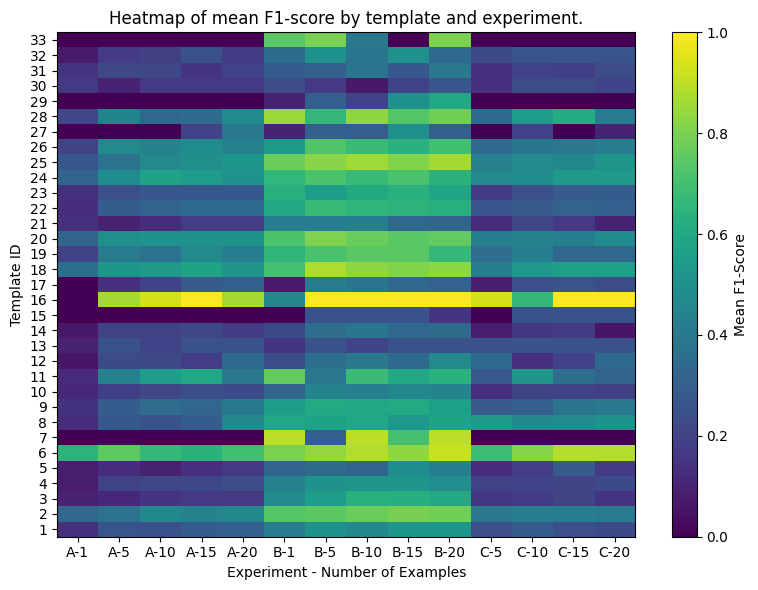

In [52]:
# 1) Agregar: média do F1-Score por (template, experiment, k)
agg = (
    df.groupby(["template", "experiment", "k"], as_index=False)["F1-Score"]
      .mean()
)

# 2) Criar coluna com rótulo das colunas: "A-1", "A-5", "C-20", etc
agg["exp_k"] = agg["experiment"].astype(str) + "-" + agg["k"].astype(str)

# 3) Pivotar: linhas = templates, colunas = experimento/k
mat = agg.pivot(index="template", columns="exp_k", values="F1-Score")

# 4) Ordenar colunas para ficar bonito (por experiment e k crescentes)
def sort_key(x):
    exp, k = x.split("-")
    return (exp, int(k))

mat = mat.reindex(sorted(mat.columns, key=sort_key), axis=1)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat.values, aspect="auto", cmap="viridis")

# ticks
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(mat.columns, rotation=0)
ax.set_xlabel("Experiment - Number of Examples")

ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(mat.index)
ax.invert_yaxis()
ax.set_ylabel("Template ID")

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean F1-Score")

plt.title("Heatmap of mean F1-score by template and experiment.")
plt.tight_layout()
plt.show()


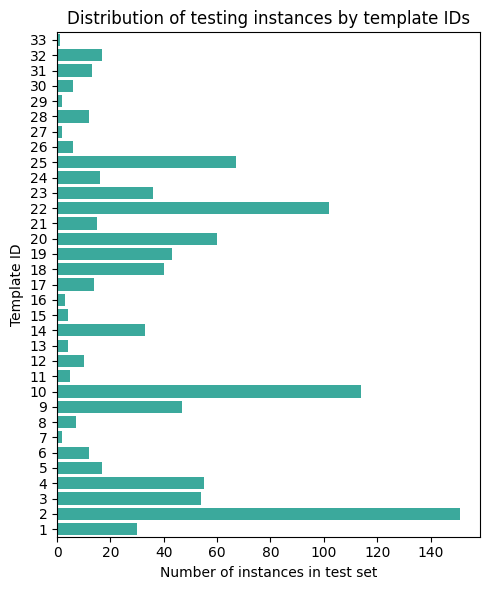

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Conta quantas vezes cada template aparece
counts = df_templates["template"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 6))

# Cor compatível com viridis
ax.barh(counts.index, counts.values, color="#3BA99C")

# Ajustar limites do eixo y
ax.set_ylim(0.5, 33.5)  # para cobrir de 1 a 33
ax.set_yticks(np.arange(1, 34, 1))  # mostra todas as numerações de 1 a 33

# Labels
ax.set_ylabel("Template ID")
ax.set_xlabel("Number of instances in test set")
ax.set_title("Distribution of testing instances by template IDs")

plt.tight_layout()
plt.show()


## Metrics by template class

In [54]:
dfA_1ex = df_exp(ExperimentType.COSINE_ONLY, 0)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=1)
dfA_5ex = df_exp(ExperimentType.COSINE_ONLY, 1)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=5)
dfA_10ex = df_exp(ExperimentType.COSINE_ONLY, 2)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=10)
dfA_15ex = df_exp(ExperimentType.COSINE_ONLY, 3)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=15)
dfA_20ex = df_exp(ExperimentType.COSINE_ONLY, 4)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="A",k=20)

dfB_1ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 0)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=1)
dfB_5ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 1)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=5)
dfB_10ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 2)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=10)
dfB_15ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 3)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=15)
dfB_20ex = df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="B",k=20)

dfC_5ex = df_exp(ExperimentType.COSINE_KMEANS, 0)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=5)
dfC_10ex = df_exp(ExperimentType.COSINE_KMEANS, 1)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=10)
dfC_15ex = df_exp(ExperimentType.COSINE_KMEANS, 2)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=15)
dfC_20ex = df_exp(ExperimentType.COSINE_KMEANS, 3)[['template_class','f1_mean']].rename(columns={'template_class': 'template', 'f1_mean': 'F1-Score'}).assign(experiment="C",k=20)

df = pd.concat([dfA_1ex, dfA_5ex, dfA_10ex, dfA_15ex, dfA_20ex,
                 dfB_1ex, dfB_5ex, dfB_10ex, dfB_15ex, dfB_20ex,
                 dfC_5ex, dfC_10ex, dfC_15ex, dfC_20ex])

df

,template,F1-Score,experiment,k
0,Definition,0.000000,A,1
1,Identification,0.000000,A,1
2,Definition,0.000000,A,1
3,Definition,0.000000,A,1
4,Verification,1.000000,A,1
...,...,...,...,...
995,Identification,1.000000,C,20
996,Counting,0.000000,C,20
997,Definition,0.000000,C,20
998,Identification,0.563636,C,20


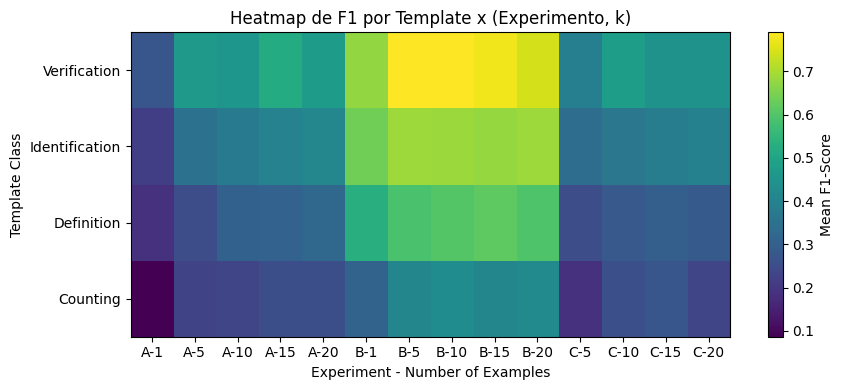

In [55]:
# 1) Agregar: média do F1-Score por (template, experiment, k)
agg = (
    df.groupby(["template", "experiment", "k"], as_index=False)["F1-Score"]
      .mean()
)

# 2) Criar coluna com rótulo das colunas: "A-1", "A-5", "C-20", etc
agg["exp_k"] = agg["experiment"].astype(str) + "-" + agg["k"].astype(str)

# 3) Pivotar: linhas = templates, colunas = experimento/k
mat = agg.pivot(index="template", columns="exp_k", values="F1-Score")

# 4) Ordenar colunas para ficar bonito (por experiment e k crescentes)
def sort_key(x):
    exp, k = x.split("-")
    return (exp, int(k))

mat = mat.reindex(sorted(mat.columns, key=sort_key), axis=1)

# 5) Plot
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(mat.values, aspect="auto", cmap="viridis")

# ticks
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(mat.columns, rotation=0)
ax.set_xlabel("Experiment - Number of Examples")

ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(mat.index)
ax.invert_yaxis()
ax.set_ylabel("Template Class")

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean F1-Score")

plt.title("Heatmap de F1 por Template x (Experimento, k)")
plt.tight_layout()
plt.show()


In [56]:
df_template_classes = dfA_1ex = df_exp(ExperimentType.COSINE_ONLY, 0)[['template_class']].rename(columns={'template_class': 'template'})
df_template_classes

,template
0,Definition
1,Identification
2,Definition
3,Definition
4,Verification
...,...
995,Identification
996,Counting
997,Definition
998,Identification


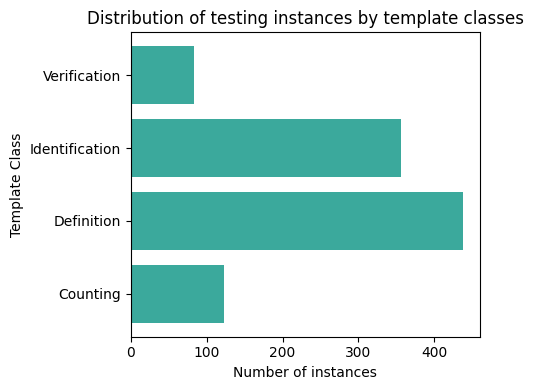

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Conta quantas vezes cada template aparece
counts = df_template_classes["template"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))

# Cor compatível com viridis
ax.barh(counts.index, counts.values, color="#3BA99C")

# Labels
ax.set_ylabel("Template Class")
ax.set_xlabel("Number of instances")
ax.set_title("Distribution of testing instances by template classes")

plt.tight_layout()
plt.show()


# Plotting

## Correlations

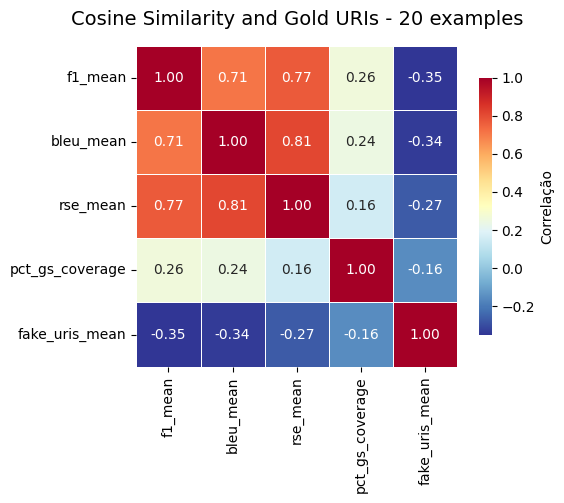

In [58]:
plot_correlations(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4), "Cosine Similarity and Gold URIs - 20 examples")

## Query-Level Metrics

In [59]:
#plot_f1_variation_A(df=df_exp(ExperimentType.COSINE_ONLY, 0), min_query_id=751, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation (Experiment considering only cosine similarity with 1 example triple in the prompt)")
#plot_f1_variation_A(df=df_exp(ExperimentType.COSINE_ONLY, 1), min_query_id=751, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation (Experiment considering only cosine similarity with 5 example triples in the prompt)")
#plot_f1_variation_A(df=df_exp(ExperimentType.COSINE_ONLY, 2), min_query_id=751, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation (Experiment considering only cosine similarity with 10 example triples in the prompt)")
#plot_f1_variation_A(df=df_exp(ExperimentType.COSINE_ONLY, 3), min_query_id=751, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation (Experiment considering only cosine similarity with 15 example triples in the prompt)")
#plot_f1_variation_A(df=df_exp(ExperimentType.COSINE_ONLY, 4), min_query_id=751, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation (Experiment considering only cosine similarity with 20 example triples in the prompt)")

plot_f1_variation_A_plotly(df=df_exp(ExperimentType.COSINE_ONLY, 0), min_query_id=1, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation <br> (Experiment considering only cosine similarity with 1 example triple in the prompt)")
plot_f1_variation_A_plotly(df=df_exp(ExperimentType.COSINE_ONLY, 1), min_query_id=1, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation <br> (Experiment considering only cosine similarity with 5 example triples in the prompt)")
plot_f1_variation_A_plotly(df=df_exp(ExperimentType.COSINE_ONLY, 2), min_query_id=1, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation <br> (Experiment considering only cosine similarity with 10 example triples in the prompt)")
plot_f1_variation_A_plotly(df=df_exp(ExperimentType.COSINE_ONLY, 3), min_query_id=1, max_query_id=1000, description="F1-Score Variation for Non-Deterministic SPARQL Query Generation <br> (Experiment considering only cosine similarity with 15 example triples in the prompt)")

## Scatter Plots

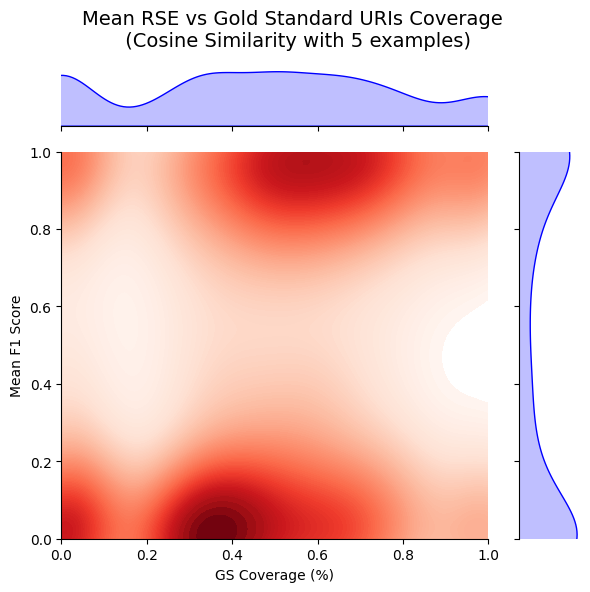

In [60]:
#plot_scatter_f1_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 0), "Mean F1 Score vs Gold Standard URIs Coverage \n (Cosine Only with 1 example)")
#plot_scatter_f1_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 1), "Mean F1 Score vs Gold Standard URIs Coverage \n (Cosine Only with 5 examples)")
#plot_scatter_f1_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 2), "Mean F1 Score vs Gold Standard URIs Coverage \n (Cosine Only with 10 examples)")
#plot_scatter_f1_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 3), "Mean F1 Score vs Gold Standard URIs Coverage \n (Cosine Only with 15 examples)")
#plot_scatter_f1_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 4), "Mean F1 Score vs Gold Standard URIs Coverage \n (Cosine Only with 20 examples)")
     
#plot_scatter_bleu_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 0), "Mean BLEU Score vs Gold Standard URIs Coverage \n (Cosine Similarity with 1 example)")
#plot_scatter_bleu_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 1), "Mean BLEU Score vs Gold Standard URIs Coverage \n (Cosine Similarity with 5 examples)")
#plot_scatter_bleu_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 2), "Mean BLEU Score vs Gold Standard URIs Coverage \n (Cosine Similarity with 10 examples)")
#plot_scatter_bleu_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 3), "Mean BLEU Score vs Gold Standard URIs Coverage \n (Cosine Similarity with 15 examples)")
#plot_scatter_bleu_gs_coverage_with_border(df_exp(ExperimentType.COSINE_KMEANS, 4), "Mean BLEU Score vs Gold Standard URIs Coverage \n (Cosine Similarity with 20 examples)")

plot_scatter_rse_gs_coverage_with_border(df_exp(ExperimentType.COSINE_AND_GOLD_URIS, 4), "Mean RSE vs Gold Standard URIs Coverage \n (Cosine Similarity with 5 examples)")